In [1]:
import numpy as np, random, matplotlib.pyplot as plt, sympy as sp

2a

In [2]:
def create_pi_a(a, b):
    pi_a = np.zeros(5)
    denom = np.sum([np.exp((k * (k - 1) / 2) * (a - b)) for k in range(1, 6)])
    for i in range(5):
        pi_a[i] = np.exp(((i + 1) * i / 2) * (a - b)) / denom
    return pi_a
pi_a = create_pi_a(0.04, 0.16)
print(pi_a)

[0.29651214 0.26298267 0.2068695  0.14432795 0.08930774]


2b

In [3]:
def create_p(a, b, K):
    p = np.zeros((5, 5))
    for i in range(5):
        if i != 4:
            p[i, i + 1] = K * np.exp(a * (i + 1))
        if i != 0:
            p[i, i - 1] = K * np.exp(b * i)
        if i == 0:
            p[i, i] = 1 - K * np.exp(a * (i + 1))
        elif i == 4:
            p[i, i] = 1 - K * np.exp(b * i)
        else:
            p[i, i] = 1 - K * np.exp(a * (i + 1)) - K * np.exp(b * i)   
    return p

In [4]:
p = create_p(0.04, 0.16, 0.1)
print(p)
for i in range(5):
    print(np.sum(p[i, :]))

[[0.89591892 0.10408108 0.         0.         0.        ]
 [0.11735109 0.77432021 0.10832871 0.         0.        ]
 [0.         0.13771278 0.74953754 0.11274969 0.        ]
 [0.         0.         0.16160744 0.72104147 0.11735109]
 [0.         0.         0.         0.18964809 0.81035191]]
1.0
1.0
1.0
0.9999999999999999
1.0


In [5]:
eigenvalues, eigenvectors = np.linalg.eig(p.T)
print(eigenvalues)

[0.52541158 0.66572977 0.81782989 1.         0.94219882]


In [6]:
pi_b = eigenvectors[:, 3]
pi_b = pi_b / np.sum(pi_b)
print(pi_b)

[0.29651214 0.26298267 0.2068695  0.14432795 0.08930774]


2c

In [7]:
res = []
i = 0
for _ in range(10 ** 6):
    u = random.random()
    if i == 0:
        if u <= p[i, i + 1]:
            i += 1
    elif i == 4:
        if u <= p[i, i - 1]:
            i -= 1
    else:
        if u <= p[i, i - 1]:
            i -= 1
        elif u <= p[i, i - 1] + p[i, i + 1]:
            i += 1
    res.append(i + 1)
pi_c = np.histogram(res, bins = np.arange(0.5, 6.5, 1), density = True)[0]
print(pi_c)


[0.294374 0.260462 0.207676 0.146008 0.09148 ]


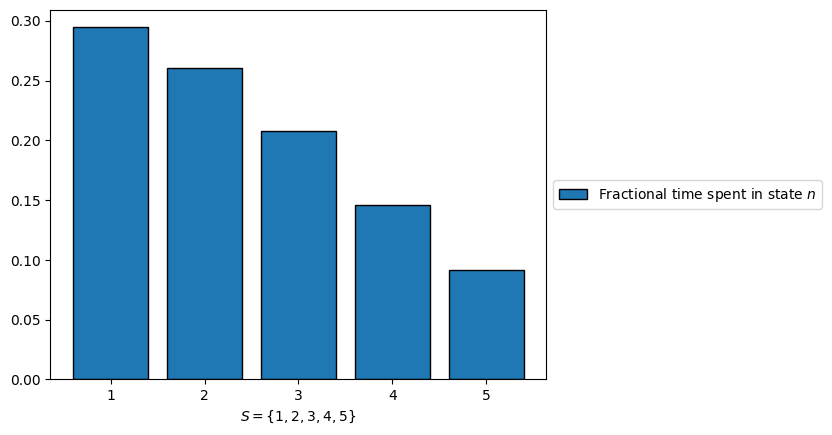

In [8]:
plt.bar(np.arange(1, 6, 1), pi_c, ec = "black", label = r"Fractional time spent in state $n$")
plt.xlabel(r"$S=\{1,2,3,4,5\}$")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/2c_1.png', dpi = 300, bbox_inches = 'tight')

2d

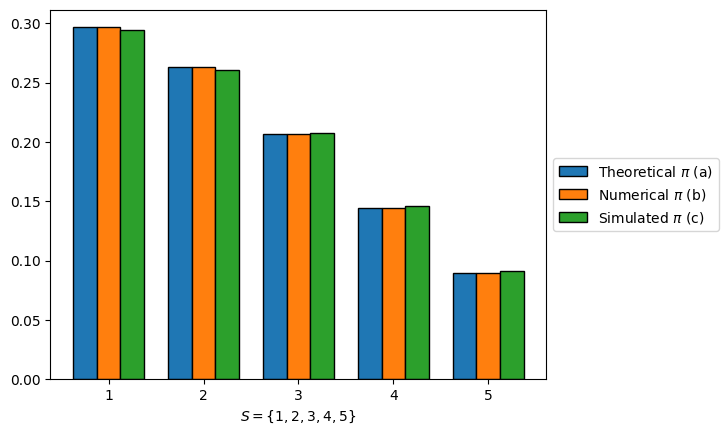

In [9]:
w = 0.25
plt.bar(np.arange(1, 6, 1) - w, pi_a, w, ec = "black", label = r"Theoretical $\pi$ (a)")
plt.bar(np.arange(1, 6, 1), pi_b, w, ec = "black", label = r"Numerical $\pi$ (b)")
plt.bar(np.arange(1, 6, 1) + w, pi_c, w, ec = "black", label = r"Simulated $\pi$ (c)")
plt.xlabel(r"$S=\{1,2,3,4,5\}$")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/2d_1.png', dpi = 300, bbox_inches = 'tight')

3b

In [10]:
a = sp.symbols('a')
p = sp.Matrix([
    [1 - a, a, 0],
    [a, 0, 1 - a],
    [0, 1 - a, a]
])
for thing in (p.T).eigenvects():
    print(thing, "\n")

(1, 1, [Matrix([
[1],
[1],
[1]])]) 

(-sqrt(3*a**2 - 3*a + 1), 1, [Matrix([
[(1 - 2*a)/(a - 1) - sqrt(3*a**2 - 3*a + 1)/(a - 1)],
[        a/(a - 1) + sqrt(3*a**2 - 3*a + 1)/(a - 1)],
[                                                 1]])]) 

(sqrt(3*a**2 - 3*a + 1), 1, [Matrix([
[(1 - 2*a)/(a - 1) + sqrt(3*a**2 - 3*a + 1)/(a - 1)],
[        a/(a - 1) - sqrt(3*a**2 - 3*a + 1)/(a - 1)],
[                                                 1]])]) 



3c

In [11]:
def create_v(a):
    v_1 = np.array([1, 1, 1]).reshape((3, 1))
    v_2 = np.array([(1 - 2 * a - np.sqrt(3 * a ** 2 - 3 * a + 1)) / (a - 1), (a + np.sqrt(3 * a ** 2 - 3 * a + 1)) / (a - 1), 1]).reshape((3, 1))
    v_3 = np.array([(1 - 2 * a + np.sqrt(3 * a ** 2 - 3 * a + 1)) / (a - 1), (a - np.sqrt(3 * a ** 2 - 3 * a + 1)) / (a - 1), 1]).reshape((3, 1))
    return v_1, v_2, v_3

def create_lambda(a):
    lambda_1 = 1
    lambda_2 = -np.sqrt(3 * a ** 2 - 3 * a + 1)
    lambda_3 = np.sqrt(3 * a ** 2 - 3 * a + 1)
    return lambda_1, lambda_2, lambda_3

In [12]:
v_1, v_2, v_3 = create_v(0.99)
lambda_1, lambda_2, lambda_3 = create_lambda(0.99)
M = np.hstack((v_1, v_2, v_3))
print(lambda_2, lambda_3)
print(M)

-0.9850380703302791 0.9850380703302791
[[   1.          196.50380703   -0.50380703]
 [   1.         -197.50380703   -0.49619297]
 [   1.            1.            1.        ]]


In [13]:
q_0 = np.array([1, 0, 0]).reshape((3, 1))
c = np.linalg.solve(M, q_0).flatten()
print(c)

[ 0.33333333  0.00253153 -0.33586486]


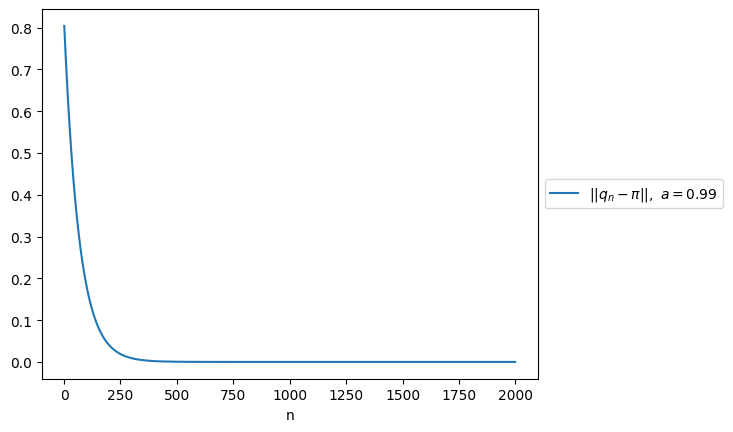

In [14]:
q_0 = np.array([1, 0, 0]).reshape((3, 1))
error = []
N = 2000
for n in range(1, N):
    e = (c[1] * lambda_2 ** n * v_2 + c[2] * lambda_3 ** n * v_3).flatten()
    error.append(np.linalg.norm(e))
plt.plot(np.arange(1, N), error, label = r"$||q_n-\pi||,\ a=0.99$")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.xlabel("n")
plt.savefig('figures/3c_1.png', dpi = 300, bbox_inches = 'tight')


3d

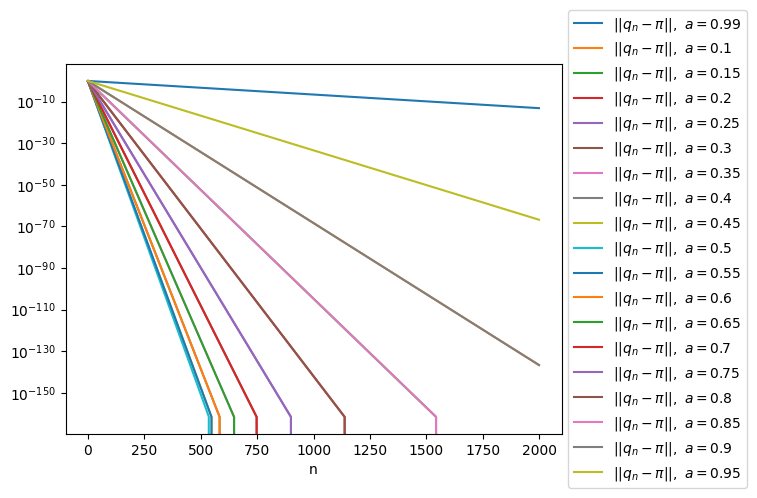

In [15]:
q_0 = np.array([1, 0, 0]).reshape((3, 1))
error = []
N = 2000
for n in range(1, N):
    e = (c[1] * lambda_2 ** n * v_2 + c[2] * lambda_3 ** n * v_3).flatten()
    error.append(np.linalg.norm(e))
plt.semilogy(np.arange(1, N), error, label = r"$||q_n-\pi||,\ a=0.99$")
plt.xlabel("n")
for a in np.arange(0.1, 1, 0.05):
    v_1, v_2, v_3 = create_v(a)
    lambda_1, lambda_2, lambda_3 = create_lambda(a)
    M = np.hstack((v_1, v_2, v_3))
    q_0 = np.array([1, 0, 0]).reshape((3, 1))
    c = np.linalg.solve(M, q_0).flatten()
    q_0 = np.array([1, 0, 0]).reshape((3, 1))
    error = []
    N = 2000
    for n in range(1, N):
        e = (c[1] * lambda_2 ** n * v_2 + c[2] * lambda_3 ** n * v_3).flatten()
        error.append(np.linalg.norm(e))
    plt.semilogy(np.arange(1, N), error, label = rf"$||q_n-\pi||,\ a={round(a, 2)}$")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/3d_1.png', dpi = 300, bbox_inches = 'tight')




3e

In [16]:
def step(s, a):
    u = random.random()
    if s == 1:
        if u <= a:
            s = 2
    elif s == 2:
        if u <= a:
            s = 1
        else:
            s = 3
    else:
        if u <= 1 - a:
            s = 2
    return s

q_n_1 = lambda n: (1 / 3) + 0.00253153 * (-0.9850380703302791) ** n * 196.50380703 + (-0.33586486) * 0.9850380703302791 ** n * (-0.50380703) # ONLY FOR a=0.99
    



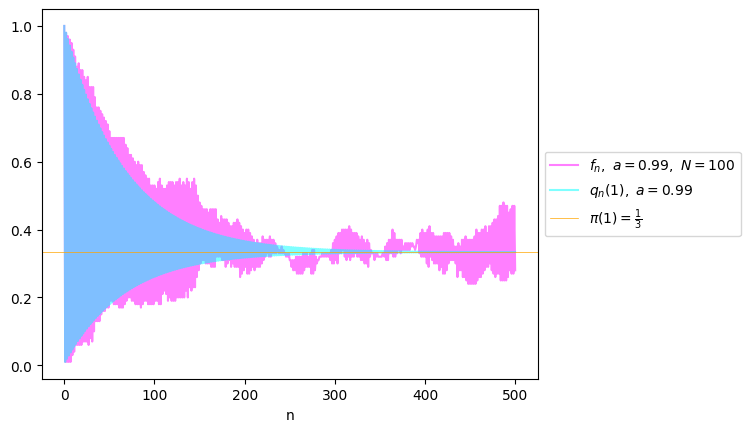

In [17]:
N = 100
chain = [1] * N
a = 0.99
count = 0
f_n = [1]
for _ in range(500):
    count = 0
    for i in range(N):
        chain[i] = step(chain[i], a)
        if chain[i] == 1:
            count += 1
    f_n.append(count / N)
plt.plot(np.arange(501), f_n, label = r"$f_n,\ a=0.99,\ N=100$", color = "fuchsia", alpha = 0.5)
plt.plot(np.arange(501), q_n_1(np.arange(501)), label = r"$q_n(1),\ a=0.99$", color = "aqua", alpha = 0.5)
plt.axhline(1 / 3, linewidth = 0.5, color = "orange", label = r"$\pi(1)=\frac{1}{3}$")
plt.xlabel("n")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/3e_1.png', dpi = 300, bbox_inches = 'tight')

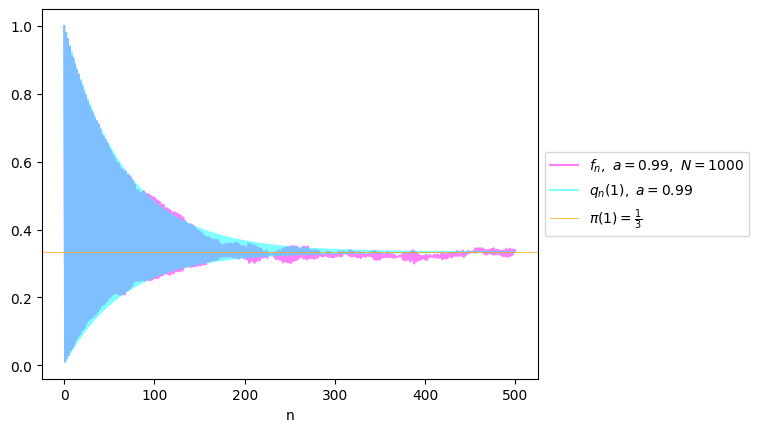

In [18]:
N = 1000
chain = [1] * N
a = 0.99
count = 0
f_n = [1]
for _ in range(500):
    count = 0
    for i in range(N):
        chain[i] = step(chain[i], a)
        if chain[i] == 1:
            count += 1
    f_n.append(count / N)
plt.plot(np.arange(501), f_n, label = r"$f_n,\ a=0.99,\ N=1000$", color = "fuchsia", alpha = 0.5)
plt.plot(np.arange(501), q_n_1(np.arange(501)), label = r"$q_n(1),\ a=0.99$", color = "aqua", alpha = 0.5)
plt.axhline(1 / 3, linewidth = 0.5, color = "orange", label = r"$\pi(1)=\frac{1}{3}$")
plt.xlabel("n")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/3e_2.png', dpi = 300, bbox_inches = 'tight')

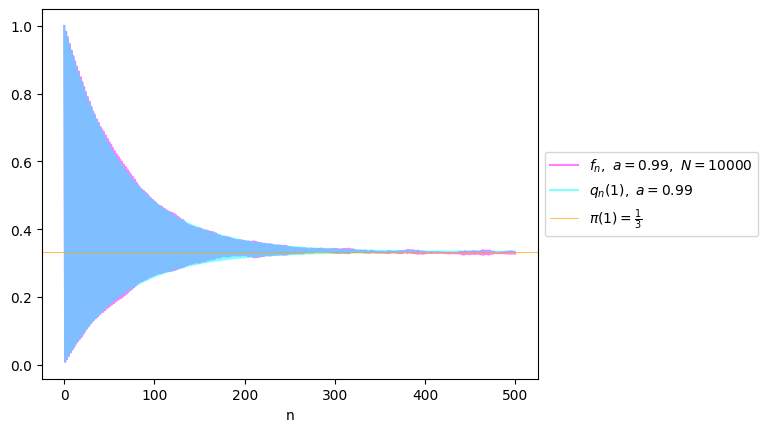

In [19]:
N = 10000
chain = [1] * N
a = 0.99
count = 0
f_n = [1]
for _ in range(500):
    count = 0
    for i in range(N):
        chain[i] = step(chain[i], a)
        if chain[i] == 1:
            count += 1
    f_n.append(count / N)
plt.plot(np.arange(501), f_n, label = r"$f_n,\ a=0.99,\ N=10000$", color = "fuchsia", alpha = 0.5)
plt.plot(np.arange(501), q_n_1(np.arange(501)), label = r"$q_n(1),\ a=0.99$", color = "aqua", alpha = 0.5)
plt.axhline(1 / 3, linewidth = 0.5, color = "orange", label = r"$\pi(1)=\frac{1}{3}$")
plt.xlabel("n")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/3e_3.png', dpi = 300, bbox_inches = 'tight')